In [11]:
!pip install -q torch torchvision transformers accelerate bitsandbytes medmnist








In [12]:
import torch
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as transforms
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

from transformers import Blip2Processor, Blip2ForConditionalGeneration
from medmnist import PneumoniaMNIST

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)


Using device: cuda


In [18]:
test_dataset = PneumoniaMNIST(split="test", download=True)

def tensor_to_pil(img):
    # If already PIL Image, just convert to RGB
    if isinstance(img, Image.Image):
        return img.convert("RGB")

    # If tensor or numpy array
    if isinstance(img, torch.Tensor):
        img = img.squeeze().numpy()
    else:
        img = np.array(img).squeeze()

    return Image.fromarray(img, mode="L").convert("RGB")


In [19]:
class PneumoniaResNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = models.resnet18(weights=None)

        # ✅ EXACT Task-1 conv layer
        self.model.conv1 = nn.Conv2d(
            1, 64, kernel_size=3, stride=1, padding=1, bias=False
        )

        self.model.fc = nn.Linear(self.model.fc.in_features, 1)

    def forward(self, x):
        return self.model(x)



In [20]:
cnn_model = PneumoniaResNet().to(device)

state_dict = torch.load("/content/resnet18_pneumonia.pth", map_location=device)
cnn_model.load_state_dict(state_dict)

cnn_model.eval()
print("✅ Task-1 CNN loaded successfully")



✅ Task-1 CNN loaded successfully


In [23]:
cnn_transform = transforms.Compose([
    transforms.ToTensor(),          # keeps 1 channel
    transforms.Normalize(mean=[0.5], std=[0.5])
])




In [25]:
correct_normal = []
correct_pneumonia = []
misclassified = []

with torch.no_grad():
    for idx in range(len(test_dataset)):
        img, label = test_dataset[idx]
        label = int(label[0])

        # 🔹 CNN INPUT (GRAYSCALE)
        if isinstance(img, Image.Image):
            gray = img.convert("L")
        else:
            gray = Image.fromarray(img.squeeze().numpy(), mode="L")

        x = cnn_transform(gray).unsqueeze(0).to(device)

        prob = torch.sigmoid(cnn_model(x)).item()
        pred = 1 if prob >= 0.5 else 0

        if pred == label:
            if label == 0 and len(correct_normal) < 5:
                correct_normal.append(idx)
            elif label == 1 and len(correct_pneumonia) < 5:
                correct_pneumonia.append(idx)
        else:
            if len(misclassified) < 5:
                misclassified.append(idx)

        if len(correct_normal) == 5 and len(correct_pneumonia) == 5 and len(misclassified) == 5:
            break

print("Correct Normal:", correct_normal)
print("Correct Pneumonia:", correct_pneumonia)
print("Misclassified:", misclassified)


Correct Normal: [3, 19, 20, 25, 27]
Correct Pneumonia: [0, 2, 4, 5, 6]
Misclassified: [1, 9, 28, 30, 39]


In [26]:
vlm_id = "Salesforce/blip2-flan-t5-xl"

processor = Blip2Processor.from_pretrained(vlm_id)
vlm = Blip2ForConditionalGeneration.from_pretrained(
    vlm_id,
    torch_dtype=torch.float16,
    device_map="auto"
)

print("VLM loaded successfully")


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


processor_config.json:   0%|          | 0.00/68.0 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/432 [00:00<?, ?B/s]

The image processor of type `BlipImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json: 0.00B [00:00, ?B/s]

...

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/1289 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie language_model.shared.weight to language_model.lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


generation_config.json:   0%|          | 0.00/168 [00:00<?, ?B/s]

VLM loaded successfully


In [27]:
prompt_simple = "Describe the medical findings in this chest X-ray."

prompt_radiologist = """
You are an expert radiologist.
Analyze this chest X-ray and provide:
1. Observations
2. Possible abnormalities
3. Clinical impression
"""


In [28]:
def generate_report(image, prompt):
    inputs = processor(images=image, text=prompt, return_tensors="pt").to(device)
    ids = vlm.generate(
        **inputs,
        max_new_tokens=200,
        temperature=0.7,
        do_sample=True
    )
    return processor.decode(ids[0], skip_special_tokens=True)


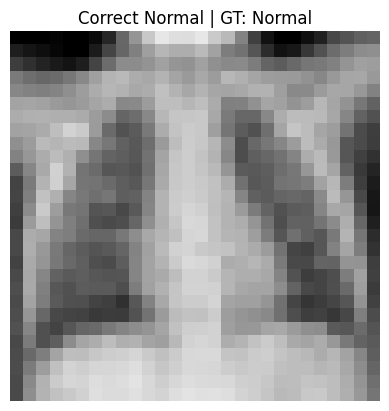

Ic. D: Infectitating blood plasma with small proteins during cell immune attack occurs more frequently once intracerbitheliocyte proliferation occurs following tissue stress when viral immune insult in particular can attack an anestrectous macrophaly cells but within limited lung in response against activ.a viral pneumonia viral epilapylaphidinemia
------------------------------------------------------------------------------------------


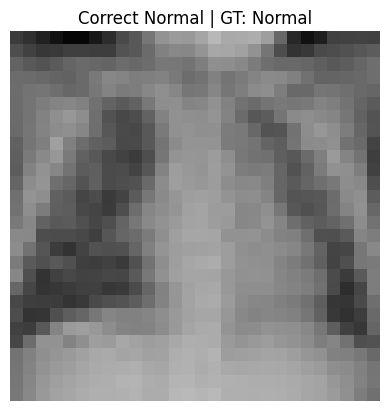

from page 338 medical diagnostic, onswer 2,336b 1. abnormal color 2. irregular findings seen above his ind well. and on ultrasound angine 2 5 11 27 35 34 46 2 20 11 13 27 18 61 228e 796v 29 23 56 2 28 5 10 41 16 34 1 31 25 30
------------------------------------------------------------------------------------------


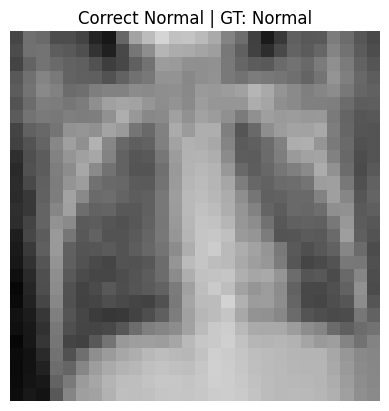

I had 3 broken hands recently while reading that washe, his arm being crushed underneath me then anatomicallists showed its size what its pattern was what would your interpretation and impression determine
------------------------------------------------------------------------------------------


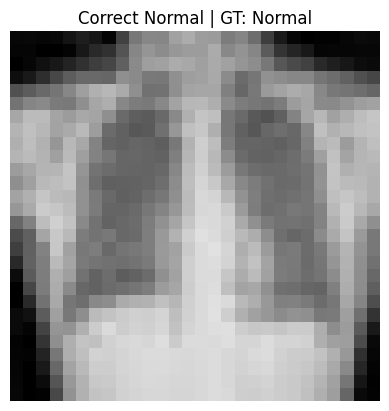

radiobiologists explain diagnostic strategies of early airscreen reading, symptoms recognition can happen as young (a 6
------------------------------------------------------------------------------------------


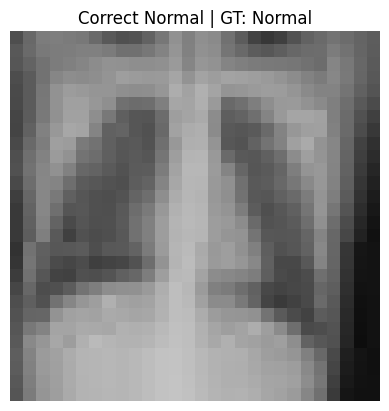

for how cancer inflate occurs at 40 weeks
------------------------------------------------------------------------------------------


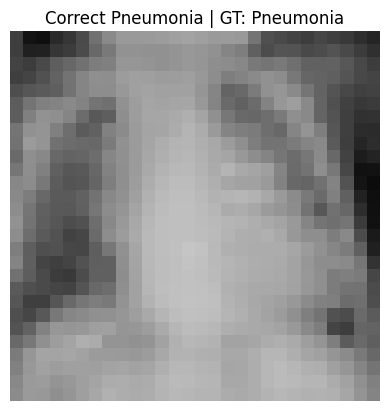

. An abnormal findings indicates to say something else within your findings of your scans should referred because either.
------------------------------------------------------------------------------------------


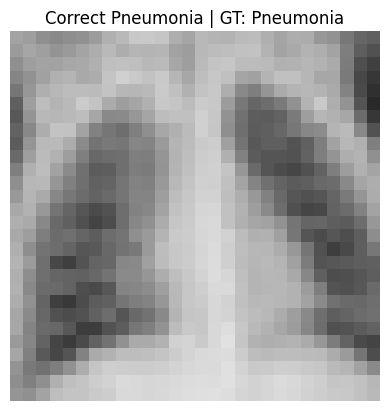

an accurate reading can enable diagnostic management early rather quickly instead seeing uncoarticuled cancer from abnormal tumor of liver by which it
------------------------------------------------------------------------------------------


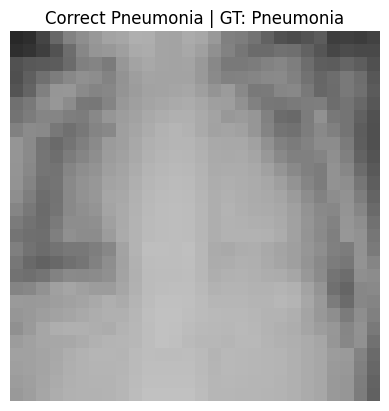

is an analysis tool software tool 2. he see some image 2. they could suggest various images that go over each angle from their points 2. maybe an unexpected value 3. bp)
------------------------------------------------------------------------------------------


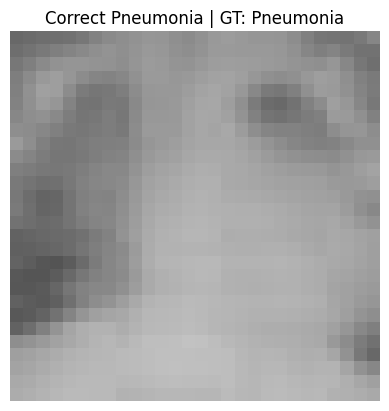

Irratians answer yes about 10 20 6 33 37 37 41 8 45 28 9 48 8 20 9 15 28 28 37 17 37 318 24 30 10 3 234 23 30 19 9 39 38 53 56 43 27 47 276 13 32 19 6 37 10 21
------------------------------------------------------------------------------------------


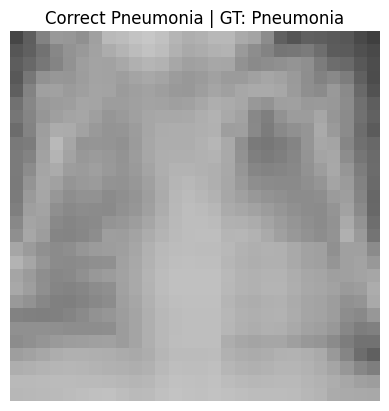

what symptoms mean
------------------------------------------------------------------------------------------


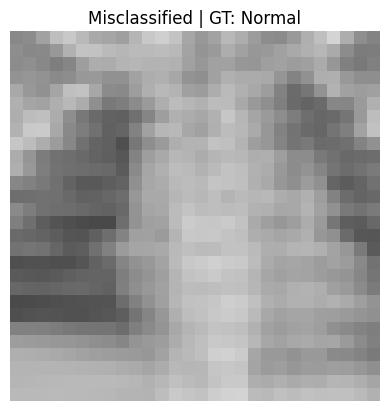

4 options in box(3,8) each correct diagnosis 3 2 answers and
------------------------------------------------------------------------------------------


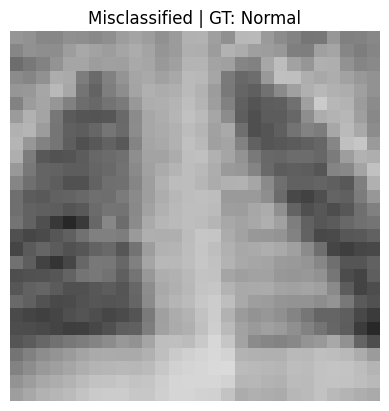

What kindest picture depict that was an image to produce image above at 100 lines; an ideal sample with very slight white dots visible beneath, while to one may seem just about equal with that to look on your plate but can cause us an uni; there are images 0 available by simply looking forward just about 25 times or about what are drawn like below just looking along those 25 straight paths shown by my doctor 4 7 times of each x from, you should say you should assume you had 1s, and provide both 2 observations the more 2 images 3 images 2 6 lines between
------------------------------------------------------------------------------------------


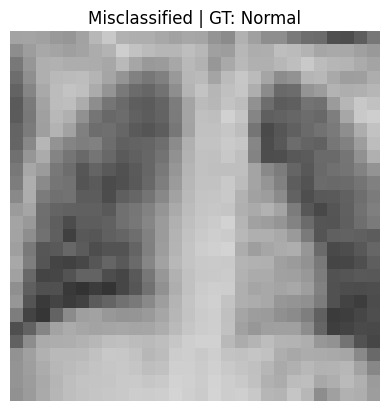

to be discussed first see one area that can identify potential risk points and help the treating personnel provide information concerning the cause cause
------------------------------------------------------------------------------------------


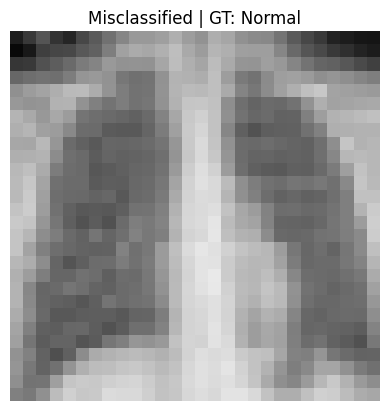

4 point chest picture 2. can cause acute lew, possibly cause lymphemia that will require supportive measures. 5. A non definitive clinical indication? 7. It doesn in its role – now and can replace that to rule other diseases for many people today 7. How could treatment that involves palpitating cano to the correct dose the type to reduce incidence complications 7 14-
------------------------------------------------------------------------------------------


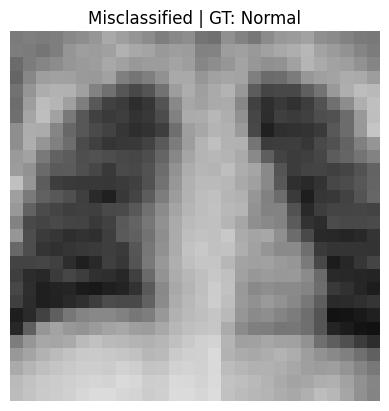

one 1 identifie these cases while taking note first impression images 2. the differential 2. for each position with two side
------------------------------------------------------------------------------------------


In [29]:
all_indices = (
    [(i, "Correct Normal") for i in correct_normal] +
    [(i, "Correct Pneumonia") for i in correct_pneumonia] +
    [(i, "Misclassified") for i in misclassified]
)

results = []

for idx, category in all_indices:
    img, label = test_dataset[idx]
    pil_img = tensor_to_pil(img)

    report = generate_report(pil_img, prompt_radiologist)

    results.append({
        "index": idx,
        "category": category,
        "ground_truth": "Pneumonia" if label[0] == 1 else "Normal",
        "report": report
    })

    plt.imshow(pil_img)
    plt.axis("off")
    plt.title(f"{category} | GT: {results[-1]['ground_truth']}")
    plt.show()

    print(report)
    print("-" * 90)


In [30]:
import os
os.makedirs("task2_outputs", exist_ok=True)

for i, r in enumerate(results):
    with open(f"task2_outputs/report_{i}.txt", "w") as f:
        f.write(
            f"Index: {r['index']}\n"
            f"Category: {r['category']}\n"
            f"Ground Truth: {r['ground_truth']}\n\n"
            f"{r['report']}"
        )
